In [4]:
##From Notes 
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=20):
    y_next = y  # Initial guess
    iteration = 0 
    for _ in range(max_iter):
        iteration += 1
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new, iteration  # Converged
        y_next = y_new
    return y_next, iteration 

# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=20):
    t_values = [t0]
    y_values = [y0]
    iterationNum = []
    h = h_init
    t = t0
    y = y0
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        # Single step with h
        y_full, _ = backward_euler_step(f, y, t, h, tol, max_iter) #Chat gpt advice for negligent value "_" and for subsequent calls of this "_"
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1, iteration = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2, iteration = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        # Error estimation
        error = abs(y_full - y_half_2)
        # Adjust step size
        if error > tol:
            h /= 2  # Decrease step size
            continue  # Retry the step with smaller h
        elif error < tol / 2:
            
            
            h *= 2  # Increase step size for efficiency
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)
        iterationNum.append(iteration)

    return np.array(t_values), np.array(y_values),np.array(iterationNum)



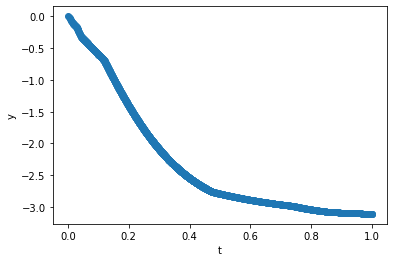

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y*y - 10

def fprime(y):
    return 2*y

y0 = 0
t0 = 0
tf = 1
h_init = 0.1

t_vals, y_vals, iterations = backward_euler_adaptive(f, y0, t0, tf, h_init)

plt.plot(t_vals, y_vals, 'o-') ##AI utilized for plot 
plt.xlabel('t')
plt.ylabel('y')
plt.show()